# Mistakes made in the previous model in terms of the PDEs for the order parameter and solute balance. The corrected equations (Pulled directly from the Karma paper) are shown below (nondimensional):

$$\bar r = \frac{r}{L_0}, \qquad \bar z = \frac{z}{L_0}, \qquad \bar t = \frac{t}{t_0}$$

$$\text{with } L_0 = W, \text{ and } t_0 = W^2/D_l$$

## Order Parameter

$$\tau \frac{\partial \phi}{\partial \bar t} = W^2 \left[ \frac{1}{\bar r} \frac{\partial}{\partial \bar r} \left ( \bar r \frac{\partial \phi}{\partial \bar r} \right) + \frac{\partial^2 \phi}{\partial \bar z^2} \right] + \phi - \phi^3 - \lambda (u + Mc_{\infty}U)(1 - \phi^2)^2$$

where

$$W = \text{diffuse interface thickness}$$

$$M = \frac{-m_L(1-k)}{L/C_{p,l}}$$

$$\lambda = \frac{15L^2}{16Hc_{p,l}T_M} = a_1 \frac{W}{d_0}$$

$$\gamma \approx 0.01 \text{J/$m^2$}, \qquad H = \frac{\gamma}{IW}, \qquad I = 2 \sqrt{2}/3, \qquad a_1 = 15I/16, \qquad d_0 = \gamma T_M c_{p,l} / L^2, \qquad a_2 = 0.6267, \qquad k = 0.10$$

$$\text{for $\beta = 0$ (Negligible interface kinetics):} \tau = a_2 \lambda \frac{W^2}{D_l} \left [ \frac{D_l}{\alpha_l} + Mc_{\infty}(1 + (1-k)U) \right ]$$

## Heat Equation

$$\frac{\partial u}{\partial \bar t} = \frac{1}{\bar r} \frac{\partial}{\partial \bar r} \left ( \bar r \bar \alpha (\phi) \frac{\partial u}{\partial \bar r} \right ) + \frac{\partial}{\partial \bar z} \left ( \bar \alpha (\phi) \frac{\partial u}{\partial \bar z} \right ) + \frac{L_h}{2} \frac{\partial \phi}{\partial \bar t}$$

where

$$u = \frac{T - T_M - m_Lc_{\infty}}{L/c_{p,l}} \to T_{liq}(c_{\infty}) = T_M + m_Lc_{\infty}, \qquad \Delta T_{ref} = \frac{L}{c_{p,l}} \to u = \frac{T - T_{liq}(c_{\infty})}{\Delta T_{ref}}$$

$$\bar \alpha(\phi) = \bar \alpha_s + \left ( \bar \alpha_l - \bar \alpha_s \right ) \frac{1 - \phi}{2}$$

$$L_h = \frac{L}{c_{p,l} \Delta T_{ref}} = 1, \qquad \bar \alpha_l = \frac{\alpha_l}{D_l}, \qquad \bar \alpha_s = \frac{\alpha_s}{D_l}$$

$$c_{p,l} = 1800 J/kg \cdot K, \qquad k_l = 0.13 W/m \cdot K, \qquad \rho_l = 778 kg/m^3, \qquad \to \alpha_l = 9.28 \times 10^{-8} m^2/s$$

$$c_{p,s} = 1500 J/kg \cdot K, \qquad k_s = 0.40 W/m \cdot K, \qquad \rho_s = 996 kg/m^3, \qquad \to \alpha_s = 2.68 \times 10^{-7} m^2/s$$

$$T_M = 279.65 K, \qquad m_L = -0.10 K/wt. \%, \qquad c_{\infty} = 25 wt. \%, \qquad L = 31.3 \times 10^3 J/kg$$

## Solute Equation

$$\left ( \frac{1+k}{2} \right ) \frac{\partial U}{\partial \bar t} = \vec \nabla \cdot \left ( D_l \frac{1 - \phi}{2} \vec \nabla U + a_t W [1 + (1-k) U] \frac{\partial \phi}{\partial \bar t} \frac{\vec \nabla \phi}{|\vec \nabla \phi|} \right ) + \frac{1}{2} \frac{\partial}{\partial \bar t} (\phi [1 + (1-k)U])$$

where

$$U = \frac{c - c_{\infty}}{c_{\infty} - kc_{\infty}}$$

$$D_l = 1 \times 10^{-11} m^2/s, \qquad D_s = 0, \qquad a_t = \frac{1}{2 \sqrt 2}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from numba import njit, prange
    _NUMBA = True
except ImportError:
    def njit(*a, **kw):          # no-op decorator — works with or without arguments
        if len(a) == 1 and callable(a[0]):
            return a[0]
        def wrap(f): return f
        return wrap
    prange = range
    _NUMBA = False
    print("Numba not found — running pure NumPy.  pip install numba to enable JIT.")

In [2]:
# SECTION 1: PHYSICAL INPUTS
# ═══════════════════════════════════════════════════════════════

# --- Domain ---
Lx_phys   = 100e-6          # [m]  radial domain
H_phys    = 0.20e-3           # cylinder height
Nr        = 500              # radial nodes — dr≈200nm, 7 pts across 500nm interface
dz_target_phys = 200e-9      # [m] match dr resolution — test whether coarse dz (prev. 1µm)
                              # was numerically suppressing the perturbation
Nz = int(round(H_phys / dz_target_phys)) + 1

# --- Phase field ---
W_phys    = 5e-7             # [m]  interface width
# lam computed below from gamma_phys/d0 (Karma thin-interface) — see new constants block
seed_lambda_phys = 10e-6      # [m] mid-range of your independent lambda_c estimate (10 um), not being used here
seed_amp_phys    = 5e-7      # [m] 500 nm equal to interface thickness

# --- Solute ---
Dl_phys   = 1e-11  # m^2/s
Ds_phys   = 0.0 # assume 0 diffusivity in the solid
k         = 0.10 # equilibrium partition coefficient
c_inf     = 25.0             # [wt%], initial liquid composition
w_inf     = c_inf / 100      # [mass fraction]

# --- Phase diagram ---
Tm             = 279.65 # melting point pure cyclohexane
m_L            = -0.100     # [K/wt%], liquidus slope
m_w            = m_L * 100  # [K/mass frac.]

# Physical temperatures — now decoupled from the wall BC
T_liq_winf     = Tm + m_w* w_inf # equilibrium temperature of initial and bulk liquid composition
T_init_phys    = T_liq_winf           # [K]  4°C uniform initial temperature
T_wall_final_phys = 273.15 - 10.0      # [K]  target wall temperature (end of ramp)
t_ramp_phys       = 30.0              # [s]  time to ramp from T_liq_winf to T_wall_final
t_soak_phys       = 30.0              # [s]  hold time at T_wall_final after ramp
# total simulated time = t_ramp_phys + t_soak_phys

# one directory per simulation condition
import json, csv, os
try:
    import h5py
    _USE_H5 = True
except ImportError:
    _USE_H5 = False
    print("h5py not installed — pip install h5py  (needed for snapshot files)")

sim_tag = (f"Twall_{T_wall_final_phys-273.15:.1f}C"
           f"_ramp{t_ramp_phys:.0f}s"
           f"_soak{t_soak_phys:.0f}s"
           f"_Dl{Dl_phys:.0e}"
           f"_H{H_phys*1e3:.1f}mm"
           f"_Nr{Nr}_Nz{Nz}")
sim_dir = f"./phasefield_output/{sim_tag}"
os.makedirs(sim_dir, exist_ok=True)
print(f"Output directory: {sim_dir}")

DeltaT_initial = T_init_phys - T_liq_winf      # reference temp is liquidus temp of bulk solution, 0 by equilibrium principles

# --- Thermal properties (phase-dependent conductivity, constant rho & Cp) ---
rho = 0.5 * (996 + 778)          # [kg/m^3] arithmetic mean — see note below
Cp  = 0.5 * (1500 + 1800)        # [J/(kg K)]

# Preserve the ORIGINAL alpha values exactly; back out equivalent conductivities.
alphaT_s_phys = 0.4  / (996 * 1500)     # unchanged target: 2.6774e-7 m^2/s
#alphaT_l_phys = 0.13 / (778 * 1800)     # unchanged target: 9.2831e-8 m^2/s
alphaT_l_phys = alphaT_s_phys # start by using the same thermal diffusivity, removes the spatial dependence of this variable

k_CH_s = alphaT_s_phys * rho * Cp       # equivalent conductivity under constant rho,Cp
k_CH_l = alphaT_l_phys * rho * Cp

assert abs(alphaT_s_phys - k_CH_s/(rho*Cp)) < 1e-15   # self-check, matches your lam_check style
assert abs(alphaT_l_phys - k_CH_l/(rho*Cp)) < 1e-15

L_phys        = 31.3e3 # latent heat of fusion for pure cyclohexane, [J/kg]

# --- Phase-field physical constants (Karma thin-interface) ---
gamma_phys = 0.40                       # [J/m^2] provisional — replace with literature/measured value
I_const    = 2.0*np.sqrt(2)/3.0         # 0.9428, universal
a1_const   = 15.0*I_const/16.0          # 0.8839
a2_const   = 0.6267                     # published, for g(phi)=phi-2phi^3/3+phi^5/5, beta=0

L_vol_phys  = L_phys * rho         # volumetric conversion — see Flag 1
cp_vol_phys = Cp * rho

H_phys_barrier = gamma_phys / (I_const * W_phys)
d0_phys        = gamma_phys * Tm * cp_vol_phys / L_vol_phys**2
lam            = a1_const * W_phys / d0_phys

lam_check = 15.0*L_vol_phys**2 / (16.0*H_phys_barrier*cp_vol_phys*Tm)
print(f"lambda check: Eq.50={lam:.4f}  Eq.48={lam_check:.4f}  (should match)")

DeltaT_ref = L_phys / Cp           # matches paper's native u — Lh=1 by construction
Mwinf      = -m_w*(1.0-k)/(L_phys/Cp) * w_inf

Lh            = L_phys / (Cp * DeltaT_ref)

assert abs(Lh - 1.0) < 1e-10, f"Lh should equal 1.0 by construction (DeltaT_ref=L/cp), got {Lh:.6f}"

print(f"DeltaT_ref = {DeltaT_ref:.4f} K")
print(f"Lh         = {L_phys/(Cp*DeltaT_ref):.4f}  u_init = {(DeltaT_initial)/DeltaT_ref:.4f}")

# --- Time ---
t_total_phys = t_ramp_phys + t_soak_phys   # total physical time to simulate [s]
# nsteps is set automatically from t_total — no manual calculation needed
# (will be computed in Section 3 after dt is known)
plot_every = 1000             # shorter run (~60s) needs finer snapshot cadence for sigma(t)
z0_phys    = 20e-6           # [m] initial solid depth from the cold wall (z=0)


Output directory: ./phasefield_output/Twall_-10.0C_ramp30s_soak30s_Dl1e-11_H0.2mm_Nr500_Nz1001
lambda check: Eq.50=2.0807  Eq.48=2.0807  (should match)
DeltaT_ref = 18.9697 K
Lh         = 1.0000  u_init = 0.0000


In [3]:
# SECTION 2: REFERENCE SCALES  (unchanged)
# ═══════════════════════════════════════════════════════════════

L0 = W_phys
t0 = W_phys**2 / Dl_phys
D0 = Dl_phys

print(f"Reference scales:  L0 = {L0:.2e} m,  t0 = {t0:.3e} s")


Reference scales:  L0 = 5.00e-07 m,  t0 = 2.500e-02 s


In [4]:
# SECTION 3: NONDIMENSIONALISATION
# ═══════════════════════════════════════════════════════════════

# --- Radial grid ---
Lx     = Lx_phys / L0
dr     = Lx / (Nr - 1)
r_nd   = np.linspace(0, Lx, Nr)
r_phys = r_nd * L0

# --- Axial grid ---
Hz     = H_phys / L0                   # nondim axial height
dz     = Hz / (Nz - 1)                 # nondim axial spacing
z_nd   = np.linspace(0, Hz, Nz)        # [Nz] nondim z coordinates
z_phys = z_nd * L0                     # [m]  physical z coordinates

# --- Scalar nondim parameters ---
W       = W_phys  / L0
Dl      = Dl_phys / D0
Ds      = Ds_phys / D0
#r0      = x0_phys / L0
z0      = z0_phys / L0
alphaT_s = alphaT_s_phys / D0          # = 2677
alphaT_l = alphaT_l_phys / D0          # =  928

tau_cfl_est = a2_const * lam * (W**2/Dl) * (Dl/alphaT_l + Mwinf*(1.0 + (1.0-k)*0.0))  # conservative, evaluated at U=0

u0_nd = DeltaT_initial / DeltaT_ref   # = (T_liq_winf - T_liq_winf) / DeltaT_ref = 0.0

u_wall_final = (T_wall_final_phys - T_liq_winf) / DeltaT_ref # Dirichlet temperature BC for bottom wall

# --- Time step: set by radial CFL ---
Fo_target = 0.40
# NEW — z-direction heat equation is now unconditionally stable (CN);
D_solute_eff = Dl * (2.0 / (1.0 + k))    # solute-eq LHS coefficient raises effective diffusive rate

dz_penalty  = (1.0/dr**2 + 1.0/dz**2)   # combined 2D explicit-diffusion stability
dt_solute2d = Fo_target / (D_solute_eff * dz_penalty)
dt_phase2d  = Fo_target / ((W**2 / tau_cfl_est) * dz_penalty)
dt = min(dt_solute2d, dt_phase2d)

nsteps = int(t_total_phys / (dt * t0)) + 1
print(f"  nsteps = {nsteps:,}  (t_total = {t_total_phys:.0f}s, "
      f"actual = {nsteps*dt*t0:.2f}s)")

# ── after nsteps is computed, add adaptive-dt bookkeeping (keep nsteps as an estimate only) ──
print(f"  nsteps estimate = {nsteps:,} (ASSUMES FIXED dt — actual step count will differ "
      f"under adaptive stepping: more steps during transients, possibly fewer once quasi-steady)")

dt_current   = dt          # start from the existing conservative estimate
dt_growth    = 1.05        # cap growth to 5%/step — avoids oscillating dt near a stability boundary
t_phys_current = 0.0       # NEW — now an accumulator, not derived from step*dt

# --- Stability checks ---
Fo_z_diff  = D_solute_eff * dt / dz**2
Fo_z_phase = W**2     * dt / (tau_cfl_est * dz**2)
Fo_r_diff  = D_solute_eff * dt / dr**2
Fo_r_phase = W**2     * dt / (tau_cfl_est * dr**2)
print(f"  Combined Fo (r+z): diff={Fo_r_diff+Fo_z_diff:.3f}, phase={Fo_r_phase+Fo_z_phase:.4f}  (both should be < 0.5)")
Fo_z_s_check = alphaT_s * dt / dz**2   # informational only — no longer a constraint
tau_T_z    = H_phys**2 / alphaT_l_phys

print(f"\nRadial: Nr={Nr}, dr={dr*L0*1e9:.0f} nm, {2*np.sqrt(2)*W/dr:.1f} pts/interface")
print(f"Axial:  Nz={Nz}, dz={dz*L0*1e6:.2f} µm,  H={H_phys*1e3:.1f} mm")
print(f"dt constrained by: r and z-explicit (phase field + solute CFL)")
print(f"  z-direction heat equation: now CN (unconditionally stable)")
print(f"  Fo_z (informational, no longer binding): {Fo_z_s_check:.2f}")
print(f"  dt_nd={dt:.6f},  dt_phys={dt*t0:.3e} s  ({dt*t0*1e6:.1f} µs)")
print(f"  dt_r_phys={dt*t0:.3e} s")
#print(f"  Fo_r: diff={Fo_r_diff:.3f}, phase={Fo_r_phase:.4f}  (< 0.5 ✓)")
print(f"  Total sim time: {nsteps*dt*t0:.2f} s  ({nsteps} steps)")
print(f"  τ_T,z = H²/α_l = {tau_T_z:.1f} s  "
      f"({'τ_T > sim time — partial thermal evolution' if tau_T_z > nsteps*dt*t0 else 'τ_T < sim time — thermal equilibrated'})")
print(f"Total nodes: {Nr}×{Nz} = {Nr*Nz:,}")

t_sim_phys = nsteps * dt * t0
print(f"  Estimated run time:")
print(f"    NumPy Thomas (no Numba): ~{nsteps*1.5e-3/60:.0f} min")
print(f"    Numba @njit Thomas:      ~{nsteps*0.3e-3/60:.1f} min")
print(f"  τ_T(H={H_phys*1e3:.1f}mm) = {H_phys**2/alphaT_l_phys:.0f}s   "
      f"t_sim = {t_sim_phys:.1f}s   "
      f"({'gradient sustained ✓' if H_phys**2/alphaT_l_phys > t_sim_phys else 'fully equilibrated'})")
print(f"  Domain: z=0 (cold wall, Dirichlet) → z=H (insulated, Neumann) — single front, no reflection")

# Dirichlet gradient stiffness: how many steps to propagate wall BC one dz
steps_per_dz = int(dz**2 / (alphaT_s * dt))
print(f"Wall BC propagation: ~{steps_per_dz} steps to advance one dz  "
      f"({steps_per_dz*dt*t0*1e3:.2f} ms physical)")

# --- Phase diagram diagnostics (unchanged) ---
T_init_K   = T_liq_winf + DeltaT_initial 
w_l_eq     = (T_init_K - Tm) / m_w
w_s_eq     = k * w_l_eq

print(f"\n--- Phase diagram ---")
print(f"  w_l_eq (tie line):    {w_l_eq*100:.2f} wt%     {w_l_eq:.4f} (mass frac.)")
print(f"  w_s_eq (solidus):     {w_s_eq*100:.2f} wt%     {w_s_eq:.4f} (mass frac.)")
print(f"  T_liq_winf = Tm + m_w×w_inf = {Tm-273.15:.2f} + ({m_w:.3f})×{w_inf:.4f} = {T_liq_winf-273.15:.4f}°C")
print(f"  w_s_eq  = k × w_inf        = {k}×{w_inf:.2f} = {k*w_inf:.3f} (mass frac.)   (solidus at T_init)")
print(f"  m_S     = m_w / k          = {m_w:.3f}/{k:.2f} = {m_w/k:.4f} K/mass frac.  (solidus slope)")
print(f"  u_init  = (T_init - T_liq_winf)/DeltaT_ref = {u0_nd:.6f}  ← must be 0.0 ✓")
print(f"  u_wall_final = (T_wall_final - T_liq_winf)/DeltaT_ref = {u_wall_final:.6f}  "
      f"{'← 0.0 = equilibrium validation (no motion)' if abs(u_wall_final)<1e-10 else f'← driving ΔT = {(T_wall_final_phys-T_liq_winf):.3f} K'}")
print(f"  Ramp: {T_liq_winf-273.15:.2f}°C → {T_wall_final_phys-273.15:.2f}°C "
      f"over {t_ramp_phys:.0f}s, then hold {t_soak_phys:.0f}s")
print(f"  ΔT wall-to-init over whole run:      {(T_wall_final_phys-T_init_phys):.2f} K  (cold wall drives solidification)")

# NEW — save all parameters so any analysis cell can reconstruct units
_params = dict(
    T_wall_final_phys=T_wall_final_phys,
    t_ramp_phys=t_ramp_phys,
    t_soak_phys=t_soak_phys,
    t_total_phys=t_total_phys,
    T_liq_winf=T_liq_winf, T_init_phys=T_init_phys,
    H_phys=H_phys, Lx_phys=Lx_phys, Nr=Nr, Nz=Nz,
    nsteps=nsteps, plot_every=plot_every, dt_phys=float(dt*t0),
    m_w=m_w, k=k, w_inf=w_inf, Tm=Tm, DeltaT_ref=DeltaT_ref,
    W_phys=W_phys, Dl_phys=Dl_phys, z0_phys=z0_phys,
    alphaT_s_phys=alphaT_s_phys, alphaT_l_phys=alphaT_l_phys,
    L0=float(L0), t0=float(t0),
    gamma_phys=gamma_phys, I_const=I_const, a1_const=a1_const, a2_const=a2_const,
    H_phys_barrier=H_phys_barrier, d0_phys=d0_phys, Mwinf=Mwinf,
    seed_lambda_phys=seed_lambda_phys, seed_amp_phys=seed_amp_phys, dz_target_phys=dz_target_phys,
)
with open(f"{sim_dir}/params.json", 'w') as _pf:
    json.dump(_params, _pf, indent=2)
print(f"params.json saved")



  nsteps = 483,789  (t_total = 60s, actual = 60.00s)
  nsteps estimate = 483,789 (ASSUMES FIXED dt — actual step count will differ under adaptive stepping: more steps during transients, possibly fewer once quasi-steady)
  Combined Fo (r+z): diff=0.113, phase=0.4000  (both should be < 0.5)

Radial: Nr=500, dr=200 nm, 7.1 pts/interface
Axial:  Nz=1001, dz=0.20 µm,  H=0.2 mm
dt constrained by: r and z-explicit (phase field + solute CFL)
  z-direction heat equation: now CN (unconditionally stable)
  Fo_z (informational, no longer binding): 830.13
  dt_nd=0.004961,  dt_phys=1.240e-04 s  (124.0 µs)
  dt_r_phys=1.240e-04 s
  Total sim time: 60.00 s  (483789 steps)
  τ_T,z = H²/α_l = 0.1 s  (τ_T < sim time — thermal equilibrated)
Total nodes: 500×1001 = 500,500
  Estimated run time:
    NumPy Thomas (no Numba): ~12 min
    Numba @njit Thomas:      ~2.4 min
  τ_T(H=0.2mm) = 0s   t_sim = 60.0s   (fully equilibrated)
  Domain: z=0 (cold wall, Dirichlet) → z=H (insulated, Neumann) — single front, 

In [5]:
# OPERATORS — NEW 2D VERSIONS
# ═══════════════════════════════════════════════════════════════
# All r-operators now work on [Nr, Nz] arrays using numpy broadcasting.
# All z-operators are new (Cartesian second differences).

@njit(cache=True)
def phi_normal_2d(phi, dr, dz):
    """Cell-centered unit normal -grad(phi)/|grad(phi)|, true 2D direction."""
    dphidr = np.zeros_like(phi); dphidz = np.zeros_like(phi)
    dphidr[1:-1, :] = (phi[2:, :] - phi[:-2, :]) / (2.0*dr)
    dphidr[0,  :]   = (phi[1, :] - phi[0, :]) / dr
    dphidr[-1, :]   = (phi[-1, :] - phi[-2, :]) / dr
    dphidz[:, 1:-1] = (phi[:, 2:] - phi[:, :-2]) / (2.0*dz)
    dphidz[:, 0]    = (phi[:, 1] - phi[:, 0]) / dz
    dphidz[:, -1]   = (phi[:, -1] - phi[:, -2]) / dz
    mag      = np.sqrt(dphidr**2 + dphidz**2)
    mag_safe = np.where(mag > 1e-6, mag, 1.0)
    scale    = np.where(mag > 1e-6, 1.0, 0.0)
    return -(dphidr/mag_safe)*scale, -(dphidz/mag_safe)*scale

@njit(cache=True)
def compute_tau_2d(U, lam, a2, W, Dl, alphaT_l, Mwinf, k):
    return a2 * lam * (W**2 / Dl) * (Dl/alphaT_l + Mwinf*(1.0 + (1.0-k)*U))

@njit(cache=True)
def laplacian_cyl_r_2d(f, r_nd, dr):
    """
    Cylindrical r-Laplacian: (1/r)∂/∂r(r·∂f/∂r)
    f shape: [Nr, Nz] — applied simultaneously to all Nz z-slices.
    CHANGE FROM 1D: r_nd[:,np.newaxis] broadcasts over the z-axis.
    """
    lap = np.zeros_like(f)
    r_mid = r_nd[1:-1].reshape(-1, 1)
    r_out = r_mid + 0.5 * dr
    r_in  = r_mid - 0.5 * dr
    lap[1:-1, :] = (r_out * (f[2:, :] - f[1:-1, :])
                  - r_in  * (f[1:-1,:] - f[:-2, :])) / (r_mid * dr**2)
    lap[0,  :]   = 4.0 * (f[1,  :] - f[0,  :]) / dr**2   # axis L'Hôpital
    lap[-1, :]   = 2.0 * (f[-2, :] - f[-1, :]) / dr**2   # outer Neumann
    return lap

@njit(cache=True)
def laplacian_z_2d(f, dz):
    """
    Cartesian z-Laplacian: ∂²f/∂z²
    f shape: [Nr, Nz].  NEW IN 2D.
    Neumann BC at z=0 and z=H (ghost-point: f[:,−1]=f[:,1], f[:,Nz]=f[:,Nz-2]).
    """
    lap = np.zeros_like(f)
    lap[:, 1:-1] = (f[:, 2:] - 2 * f[:, 1:-1] + f[:, :-2]) / dz**2
    lap[:, 0]    = 2.0 * (f[:, 1]  - f[:, 0])  / dz**2   # bottom Neumann
    lap[:, -1]   = 2.0 * (f[:, -2] - f[:, -1]) / dz**2   # top Neumann
    return lap

@njit(cache=True)
def laplacian_z_var_2d(f, alpha_field, dz):
    """
    Variable-α z-Laplacian: ∂/∂z(α(φ)·∂f/∂z)
    f, alpha_field shape: [Nr, Nz].  NEW IN 2D.
    Used for the heat equation z-direction (explicit step).
    """
    alpha_fz = 0.5 * (alpha_field[:, :-1] + alpha_field[:, 1:])  # [Nr, Nz-1] face values
    lap      = np.zeros_like(f)
    lap[:, 1:-1] = (alpha_fz[:, 1:]  * (f[:, 2:]  - f[:, 1:-1])
                  - alpha_fz[:, :-1] * (f[:, 1:-1] - f[:, :-2])) / dz**2
    lap[:, 0]    = 2.0 * alpha_fz[:, 0]  * (f[:, 1]  - f[:, 0])  / dz**2  # bottom
    lap[:, -1]   = 2.0 * alpha_fz[:, -1] * (f[:, -2] - f[:, -1]) / dz**2  # top
    return lap

@njit(cache=True)
def total_flux_cyl_r_2d(U, phi, dphi_dt, n_r, Dl, Ds, k, W, a_t, dr, r_nd):
    """
    Cylindrical r-flux divergence: (1/r)∂/∂r(r[D∂U/∂r + j_at,r])
    Arrays shape: [Nr, Nz]. Applied to all z-slices simultaneously.
    CHANGE FROM 1D: arrays are 2D; broadcasting replaces 1D indexing.
    Anti-trapping uses only r-component (valid while ∂φ/∂z ≈ 0).
    When z-variations develop (non-cylindrical interface), j_at must
    include the z-component: j_at_r *= (∂φ/∂r)/|∇φ|. TODO for later.
    """
    Dphi   = Ds + (Dl - Ds) * (1.0 - phi) / 2.0
    D_half = 0.5 * (Dphi[1:, :] + Dphi[:-1, :])
    dUdr   = (U[1:, :] - U[:-1, :]) / dr
    J_diff = D_half * dUdr

    n_r_face     = 0.5 * (n_r[1:, :] + n_r[:-1, :])
    dphi_dt_half = 0.5 * (dphi_dt[1:, :] + dphi_dt[:-1, :])
    U_half       = 0.5 * (U[1:, :] + U[:-1, :])
    J_at         = a_t * W * (1.0 + (1.0 - k) * U_half) * dphi_dt_half * n_r_face

    J_total  = J_diff + J_at
    r_faces  = 0.5 * (r_nd[:-1].reshape(-1, 1) + r_nd[1:].reshape(-1, 1))
    r_mid    = r_nd[1:-1].reshape(-1, 1)
    div = np.zeros_like(U)
    div[1:-1, :] = (r_faces[1:] * J_total[1:, :] - r_faces[:-1] * J_total[:-1, :]) / (r_mid * dr)
    div[0, :]    = 4.0 * J_total[0, :] / dr
    return div

@njit(cache=True)
def flux_div_z_2d(U, phi, dphi_dt, n_z, Dl, Ds, k, W, a_t, dz):
    """
    Cartesian z-flux divergence: ∂/∂z(D(φ)·∂U/∂z)
    NEW IN 2D. Anti-trapping in z for this implementation.
    Arrays shape: [Nr, Nz].
    """
    Dphi   = Ds + (Dl - Ds) * (1.0 - phi) / 2.0
    D_fz   = 0.5 * (Dphi[:, :-1] + Dphi[:, 1:])
    J_diff = D_fz * (U[:, 1:] - U[:, :-1]) / dz

    n_z_face     = 0.5 * (n_z[:, 1:] + n_z[:, :-1])
    dphi_dt_face = 0.5 * (dphi_dt[:, 1:] + dphi_dt[:, :-1])
    U_face       = 0.5 * (U[:, 1:] + U[:, :-1])
    J_at         = a_t * W * (1.0 + (1.0 - k) * U_face) * dphi_dt_face * n_z_face

    J_z    = J_diff + J_at
    div    = np.zeros_like(U)
    div[:, 1:-1] = (J_z[:, 1:] - J_z[:, :-1]) / dz
    div[:, 0]    = 2.0 * J_z[:, 0]  / dz
    div[:, -1]   = 0.0
    return div

a_t = 1.0 / (2.0 * np.sqrt(2))

# ═══════════════════════════════════════════════════════════════
@njit(cache=True)
def _build_cn_batch(phi_int, alphaT_s, alphaT_l, dt, dr, r_nd, Nr, Ni):
    """
    Build CN tridiagonal coefficients for ALL Ni = Nz-2 interior z-slices at once.
    phi_int: [Nr, Ni]   — phi field at interior z-slices only (phi[:,1:-1]).
    Returns sub, main_, sup_: each [Nr, Ni].
    Replaces the per-slice build inside the old scipy CN loop.
    No Python loop over Nz — fully vectorised over z.
    """
    alpha  = alphaT_s + (alphaT_l - alphaT_s) * (1.0 - phi_int) / 2.0  # [Nr, Ni]
    a_face = 0.5 * (alpha[:-1, :] + alpha[1:, :])                        # [Nr-1, Ni]
    r_col  = r_nd[1:-1].reshape(-1, 1)
    rf_out = (0.5 * (r_nd[1:-1] + r_nd[2:])).reshape(-1, 1)
    rf_in  = (0.5 * (r_nd[:-2]  + r_nd[1:-1])).reshape(-1, 1)

    beta_out = dt / (2.0 * dr**2) * rf_out * a_face[1:,  :] / r_col    # [Nr-2, Ni]
    beta_in  = dt / (2.0 * dr**2) * rf_in  * a_face[:-1, :] / r_col    # [Nr-2, Ni]

    main_ = np.ones( (Nr, Ni))
    sub   = np.zeros((Nr, Ni))
    sup_  = np.zeros((Nr, Ni))

    main_[1:-1, :] += beta_out + beta_in
    sub[1:-1,   :]  = -beta_in
    sup_[1:-1,  :]  = -beta_out

    # Axis node (i=0) — L'Hôpital
    ax_c        = 2.0 * dt / dr**2 * a_face[0, :]   # [Ni]
    main_[0, :] += ax_c
    sup_[0,  :]  = -ax_c

    # Outer Neumann (i=Nr-1)
    nc           = dt / dr**2 * a_face[-1, :]        # [Ni]
    main_[-1, :] += nc
    sub[-1,   :]  = -nc

    return sub, main_, sup_

# ═══════════════════════════════════════════════════════════════
@njit(cache=True)
def _build_cn_z_batch(phi, alphaT_s, alphaT_l, dt, dz, Nr, Nz,
                      dirichlet_top=True):
    """
    Build CN z-direction tridiagonal for all Nr r-nodes simultaneously.
    Returns sub, main_, sup_: each [Ni, Nr].
    dirichlet_top=True  (full domain):  Ni=Nz-2, solves z=1..Nz-2
    dirichlet_top=False (symmetry):     Ni=Nz-1, solves z=1..Nz-1
      Last row: Neumann ghost u[Nz]=u[Nz-2] for z=Nz-1 symmetry plane.

    PERFORMANCE: inner r-loop replaced by vectorized [Nr] slice operations.
    Outer loop runs Ni=Nz-1=7500 iterations; each iteration does Nr=500
    element SIMD ops instead of a scalar loop — ~5× faster for large Nz.
    """
    alpha  = alphaT_s + (alphaT_l - alphaT_s) * (1.0 - phi) / 2.0   # [Nr, Nz]
    a_face = 0.5 * (alpha[:, :-1] + alpha[:, 1:])                     # [Nr, Nz-1]
    coeff  = dt / (2.0 * dz * dz)

    Ni    = Nz - 2 if dirichlet_top else Nz - 1
    main_ = np.ones((Ni, Nr))
    sub   = np.zeros((Ni, Nr))
    sup_  = np.zeros((Ni, Nr))

    # Interior rows: row j in [0, n_int)
    # Row j (interior index) corresponds to actual z-node j+1.
    # Face below j+1: a_face[:, j]; face above j+1: a_face[:, j+1]
    # Vectorise over the Nr axis — Numba SIMD-compiles [Nr] slice ops.
    n_int = Ni if dirichlet_top else Ni - 1

    for j in range(n_int):
        b_bel = coeff * a_face[:, j]        # [Nr] — face between z=j and z=j+1
        b_abo = coeff * a_face[:, j + 1]    # [Nr] — face between z=j+1 and z=j+2
        main_[j, :] += b_bel + b_abo
        if j > 0:
            sub[j, :] = -b_bel
        sup_[j, :] = -b_abo

    if not dirichlet_top:
        # Row Ni-1 (actual z = Nz-1): Neumann symmetry plane.
        # Ghost u[Nz] = u[Nz-2] → L_z u[Nz-1] = 2*a_face[:,Nz-2]/dz² * (u[Nz-2]-u[Nz-1])
        # CN row: main = 1+2β, sub = -2β, sup = 0  (VERIFIED: -2β not -β)
        jN = Ni - 1           # interior index Ni-1 → a_face index Nz-2 (always valid)
        b  = coeff * a_face[:, jN]          # [Nr]
        main_[jN, :] += 2.0 * b
        sub[jN,   :] = -2.0 * b
        sup_[jN,  :] = 0.0

    return sub, main_, sup_

# ═══════════════════════════════════════════════════════════════
@njit(cache=True)
def _thomas_batch(sub, main_, sup_, rhs_):
    """
    Batch Thomas tridiagonal solver.
    sub, main_, sup_, rhs_: shape [Nr, Ni].
    Solves Ni independent tridiagonal systems simultaneously.

    The loop runs over Nr = 500 rows — each iteration does vectorised
    operations over Ni = 998 columns (all interior z-slices at once).
    This replaces the old loop of Nz scipy.solve_banded calls:
      Old: Nz × 0.5 ms Python overhead  → 500 ms per step at Nz=1000
      New: Nr × ~2 µs numpy op          →   1 ms per step at ANY Nz
      With @njit: Nr × ~5 ns            →   2 µs per step

    Without Numba the decorator is a no-op and it runs as pure NumPy —
    still ~125x faster than the scipy loop for Nz=1000.
    """
    Nr, Ni = rhs_.shape
    c_ = np.empty_like(sup_)
    d_ = np.empty_like(rhs_)
    x  = np.empty_like(rhs_)

    # Forward elimination
    c_[0, :] = sup_[0, :] / main_[0, :]
    d_[0, :] = rhs_[0, :] / main_[0, :]
    for i in range(1, Nr):
        denom    = main_[i, :] - sub[i, :] * c_[i-1, :]
        c_[i, :] = sup_[i, :] / denom
        d_[i, :] = (rhs_[i, :] - sub[i, :] * d_[i-1, :]) / denom

    # Back substitution
    x[Nr-1, :] = d_[Nr-1, :]
    for i in range(Nr-2, -1, -1):
        x[i, :] = d_[i, :] - c_[i, :] * x[i+1, :]
    return x

In [6]:
# INITIAL CONDITIONS
# CHANGE FROM 1D: all fields broadcast from 1D r-profile → [Nr, Nz]
# ═══════════════════════════════════════════════════════════════

#r0_seeded = r0 + (seed_amp_phys / L0) * np.sin(2*np.pi*(z_nd*L0 - H_phys) / seed_lambda_phys + np.pi/4)
#phi = -np.tanh((r_nd[:, np.newaxis] - r0_seeded[np.newaxis, :]) / (np.sqrt(2) * W))

# Perturbation now must vary with r (the front lies along z), not with z as before.
# Set seed_amp_phys = 0.0 for a perfectly flat start — see note below on why you likely want this off initially.
#z0_seeded = z0 + (seed_amp_phys / L0) * np.sin(2*np.pi*r_nd*L0 / seed_lambda_phys + np.pi/4)

_perturbation_rng_seed = 20260822          # record this value — needed for reproducibility
_rng = np.random.default_rng(seed=_perturbation_rng_seed)
noise_r = _rng.uniform(-1.0, 1.0, size=Nr)
z0_seeded = z0 + (seed_amp_phys / L0) * noise_r

phi = -np.tanh((z_nd[np.newaxis, :] - z0_seeded[:, np.newaxis]) / (np.sqrt(2) * W))

U      = np.zeros((Nr, Nz))
u      = u0_nd * np.ones((Nr, Nz))

i0_arr = np.full(Nr, int(round(z0 / dz)), dtype=int)   # seed at the IC's interface index
z_int_arr = np.full(Nr, z0, dtype=float)

/tmp/ipykernel_3414047/132566984.py:16: RuntimeWarning: divide by zero encountered in divide
  wavelengths = np.where(freqs > 0, 1.0 / freqs, np.inf)   # meters


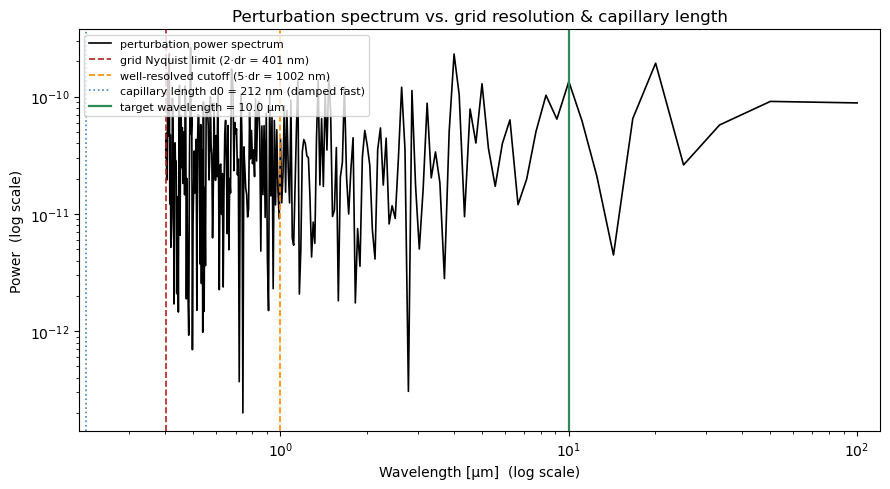


--- Grid resolution check ---
  dr_phys              = 200.4 nm
  Nyquist limit (2·dr) = 400.8 nm
  Safe cutoff (5·dr)   = 1002.0 nm
  Fraction of perturbation power at unresolved wavelengths (<5·dr): 58.1%
  ⚠ mostly unresolved noise — see Fix 1/2


In [7]:
# IC DIAGNOSTICS
# Checking that the scales of everything will allow evolution on 
# the gridspacing
# ═══════════════════════════════════════════════════════════════

# --- Physical length scales, all in meters ---
dr_phys       = dr * L0                     # radial grid spacing [m]
nyquist_phys  = 2.0 * dr_phys                # shortest representable wavelength
well_resolved = 5.0 * dr_phys                # ~5 pts/wavelength "safe" cutoff
 
# --- Power spectrum of the actual seeded perturbation (physical units) ---
signal   = (z0_seeded - z0) * L0            # perturbation only, in meters
n        = len(signal)
freqs    = np.fft.rfftfreq(n, d=dr_phys)    # cycles / meter
spectrum = np.abs(np.fft.rfft(signal))**2
wavelengths = np.where(freqs > 0, 1.0 / freqs, np.inf)   # meters
 
fig_res, ax_res = plt.subplots(1, 1, figsize=(9, 5))
 
ax_res.loglog(wavelengths[1:] * 1e6, spectrum[1:], 'k-', lw=1.2,
              label='perturbation power spectrum')
 
ax_res.axvline(nyquist_phys * 1e6, color='firebrick', ls='--', lw=1.2,
               label=f'grid Nyquist limit (2·dr = {nyquist_phys*1e9:.0f} nm)')
ax_res.axvline(well_resolved * 1e6, color='darkorange', ls='--', lw=1.2,
               label=f'well-resolved cutoff (5·dr = {well_resolved*1e9:.0f} nm)')
ax_res.axvline(d0_phys * 1e6, color='steelblue', ls=':', lw=1.2,
               label=f'capillary length d0 = {d0_phys*1e9:.0f} nm (damped fast)')
ax_res.axvline(seed_lambda_phys * 1e6, color='seagreen', ls='-', lw=1.6,
               label=f'target wavelength = {seed_lambda_phys*1e6:.1f} µm')
 
ax_res.set_xlabel('Wavelength [µm]  (log scale)')
ax_res.set_ylabel('Power  (log scale)')
ax_res.set_title('Perturbation spectrum vs. grid resolution & capillary length')
ax_res.legend(fontsize=8, loc='upper left')
ax_res.set_xlim(nyquist_phys * 1e6 * 0.5, wavelengths[1] * 1e6 * 1.2)
 
plt.tight_layout()
fig_res.savefig(f'{sim_dir}/perturbation_resolution_check.png', dpi=120, bbox_inches='tight')
plt.show()
 
# --- Quantitative check: fraction of power below the safe cutoff ---
_below_safe = wavelengths[1:] < well_resolved
_frac_unresolved = spectrum[1:][_below_safe].sum() / spectrum[1:].sum()
print(f"\n--- Grid resolution check ---")
print(f"  dr_phys              = {dr_phys*1e9:.1f} nm")
print(f"  Nyquist limit (2·dr) = {nyquist_phys*1e9:.1f} nm")
print(f"  Safe cutoff (5·dr)   = {well_resolved*1e9:.1f} nm")
print(f"  Fraction of perturbation power at unresolved wavelengths (<5·dr): "
      f"{_frac_unresolved*100:.1f}%")
print(f"  {'⚠ mostly unresolved noise — see Fix 1/2' if _frac_unresolved > 0.1 else '✓ perturbation is well resolved'}")
 

In [13]:
# PRE-RUN DIAGNOSTIC 6: points-per-interface, both directions
# ═══════════════════════════════════════════════════════════════
pts_per_W_r = (np.sqrt(2) * W_phys) / dr_phys   # physical interface half-width-ish scale / dr
pts_per_W_z = (np.sqrt(2) * W_phys) / dz         # dz here is nondim; convert to phys first
dz_phys     = dz * L0
pts_per_W_z = (np.sqrt(2) * W_phys) / dz_phys

print("--- Points across interface ---")
print(f"  r-direction: {pts_per_W_r:.1f} pts  (dr={dr_phys*1e9:.0f} nm)   "
      f"{'✓' if pts_per_W_r >= 5 else '⚠ under-resolved (<5 pts) — coarsen interface or refine dr'}")
print(f"  z-direction: {pts_per_W_z:.1f} pts  (dz={dz_phys*1e9:.0f} nm)   "
      f"{'✓' if pts_per_W_z >= 5 else '⚠ under-resolved (<5 pts) — coarsen interface or refine dz'}\n")


# ═══════════════════════════════════════════════════════════════
# PRE-RUN DIAGNOSTIC 7: capillary length vs grid spacing
# ═══════════════════════════════════════════════════════════════
print("--- Capillary length resolution ---")
print(f"  d0_phys = {d0_phys*1e9:.1f} nm")
print(f"  dr_phys = {dr_phys*1e9:.1f} nm   ratio d0/dr = {d0_phys/dr_phys:.2f}  "
      f"{'✓ resolved' if d0_phys/dr_phys >= 1 else '⚠ d0 is sub-grid in r — curvature effects invisible to the mesh'}")
print(f"  dz_phys = {dz_phys*1e9:.1f} nm   ratio d0/dz = {d0_phys/dz_phys:.2f}  "
      f"{'✓ resolved' if d0_phys/dz_phys >= 1 else '⚠ d0 is sub-grid in z — curvature effects invisible to the mesh'}\n")


# ═══════════════════════════════════════════════════════════════
# PRE-RUN DIAGNOSTIC 8: solute diffusion length — thin-interface check
# ═══════════════════════════════════════════════════════════════
# Reuses V_est_phys from the MS-band diagnostic (still a rough placeholder —
# recompute with a measured V once you have one).
l_D_phys = Dl_phys / V_est_phys   # solute diffusion length ahead of the front

print("--- Thin-interface / solute boundary layer resolution ---")
print(f"  l_D (solute diffusion length) = {l_D_phys*1e6:.2f} um")
print(f"  W_phys / l_D  = {W_phys/l_D_phys:.4f}   "
      f"{'✓ W << l_D, thin-interface asymptotics valid' if W_phys/l_D_phys < 0.1 else '⚠ W not much smaller than l_D — thin-interface limit questionable'}")
print(f"  dz_phys / l_D = {dz_phys/l_D_phys:.4f}   "
      f"{'✓ grid resolves the solute boundary layer' if dz_phys/l_D_phys < 0.2 else '⚠ grid too coarse to resolve l_D — boundary layer invisible to mesh'}\n")


# ═══════════════════════════════════════════════════════════════
# PRE-RUN DIAGNOSTIC 9: grid Peclet number (solute transport)
# ═══════════════════════════════════════════════════════════════
Pe_grid = V_est_phys * dz_phys / Dl_phys

print("--- Grid Peclet number (solute) ---")
print(f"  Pe = V*dz/Dl = {Pe_grid:.3f}   "
      f"{'✓ diffusion-dominated at grid scale' if Pe_grid < 2 else '⚠ Pe > 2 — central differencing may show non-physical oscillations'}\n")

print("NOTE: diagnostics 8-9 use the same placeholder V_est_phys from the MS-band "
      "check — recompute both once you have a measured front velocity from a trial run.")

--- Points across interface ---
  r-direction: 3.5 pts  (dr=200 nm)   ⚠ under-resolved (<5 pts) — coarsen interface or refine dr
  z-direction: 3.5 pts  (dz=200 nm)   ⚠ under-resolved (<5 pts) — coarsen interface or refine dz

--- Capillary length resolution ---
  d0_phys = 212.4 nm
  dr_phys = 200.4 nm   ratio d0/dr = 1.06  ✓ resolved
  dz_phys = 200.0 nm   ratio d0/dz = 1.06  ✓ resolved

--- Thin-interface / solute boundary layer resolution ---
  l_D (solute diffusion length) = 0.01 um
  W_phys / l_D  = 66.9344   ⚠ W not much smaller than l_D — thin-interface limit questionable
  dz_phys / l_D = 26.7738   ⚠ grid too coarse to resolve l_D — boundary layer invisible to mesh

--- Grid Peclet number (solute) ---
  Pe = V*dz/Dl = 26.774   ⚠ Pe > 2 — central differencing may show non-physical oscillations

NOTE: diagnostics 8-9 use the same placeholder V_est_phys from the MS-band check — recompute both once you have a measured front velocity from a trial run.


--- Mullins-Sekerka rough instability band (V_est = 1.34e-03 m/s) ---
  lambda_min (surface-tension cutoff): 0.00 um
  lambda_max (diffusion-length cutoff): 0.05 um
  seed_lambda_phys = 10.00 um  -> OUTSIDE estimated band — may not grow, reconsider seed_lambda_phys
  NOTE: V_est is a rough placeholder. Re-run with a measured V for a real check.

--- Domain size vs wavelength ---
  Lx_phys / seed_lambda_phys = 10.0 wavelengths across the domain
  OK — comfortably separated from edge effects

--- IC width sanity check (r=0 slice) ---
  W_phys (intended)     = 500.0 nm
  W_fit_phys (measured) = 500.0 nm
  relative error: 0.00%  ✓



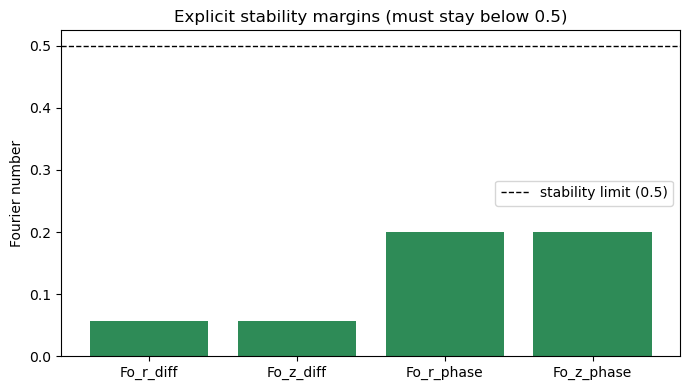

In [ ]:
# PRE-RUN DIAGNOSTIC 1: Mullins-Sekerka unstable wavelength band
# ═══════════════════════════════════════════════════════════════
# Quasi-steady MS estimate for a directional front. This is a first-pass
# SANITY CHECK, not a precise prediction — V_est below is a rough guess.
# Once you have a short trial run, replace V_est_phys with an actual
# measured front velocity (from consecutive z_int_um in scalars.csv)
# and rerun this cell for a much better estimate.

Gamma_phys = gamma_phys * Tm / L_vol_phys      # Gibbs-Thomson coefficient [m*K]

# crude velocity estimate: thermal diffusion length / soak time
V_est_phys = alphaT_l_phys / H_phys            # [m/s] — REPLACE with measured V once available

# concentration gradient at the interface, quasi-steady boundary layer:
# dC/dz|int ~ (C_l* - C_inf) * V / D_l ,  with C_l* = C_inf/k  (order-of-magnitude)
dCdz_int = (w_inf/k - w_inf) * V_est_phys / Dl_phys
G_c_equiv = abs(m_w) * dCdz_int                # constitutional-supercooling-equivalent gradient [K/m]

lambda_min_phys = 2*np.pi*np.sqrt(Gamma_phys * Dl_phys / (G_c_equiv * V_est_phys + 1e-300))
lambda_max_phys = 2*np.pi*Dl_phys / V_est_phys  # diffusion length cutoff, upper bound of active band

print("--- Mullins-Sekerka rough instability band (V_est = {:.2e} m/s) ---".format(V_est_phys))
print(f"  lambda_min (surface-tension cutoff): {lambda_min_phys*1e6:.2f} um")
print(f"  lambda_max (diffusion-length cutoff): {lambda_max_phys*1e6:.2f} um")
print(f"  seed_lambda_phys = {seed_lambda_phys*1e6:.2f} um  -> "
      f"{'INSIDE unstable band (reasonable choice)' if lambda_min_phys < seed_lambda_phys < lambda_max_phys else 'OUTSIDE estimated band — may not grow, reconsider seed_lambda_phys'}")
print("  NOTE: V_est is a rough placeholder. Re-run with a measured V for a real check.\n")

# ═══════════════════════════════════════════════════════════════
# PRE-RUN DIAGNOSTIC 2: domain size vs. perturbation wavelength
# ═══════════════════════════════════════════════════════════════
n_wavelengths = Lx_phys / seed_lambda_phys
print("--- Domain size vs wavelength ---")
print(f"  Lx_phys / seed_lambda_phys = {n_wavelengths:.1f} wavelengths across the domain")
print(f"  {'OK — comfortably separated from edge effects' if n_wavelengths >= 5 else '⚠ fewer than 5 wavelengths fit — edge effects may contaminate the result'}\n")


# ═══════════════════════════════════════════════════════════════
# PRE-RUN DIAGNOSTIC 3: does the coded IC actually have width W?
# ═══════════════════════════════════════════════════════════════
# Fit the analytic tanh form to the actual phi(z) at r=0 and back out
# the effective width, to catch silent scaling errors before running.

from scipy.optimize import curve_fit

def _tanh_model(z, z0_fit, w_fit):
    return -np.tanh((z - z0_fit) / (np.sqrt(2) * w_fit))

_phi_r0 = phi[0, :]
_popt, _ = curve_fit(_tanh_model, z_nd, _phi_r0, p0=[z0, W])
_z0_fit_nd, _W_fit_nd = _popt
_W_fit_phys = _W_fit_nd * L0

print("--- IC width sanity check (r=0 slice) ---")
print(f"  W_phys (intended)     = {W_phys*1e9:.1f} nm")
print(f"  W_fit_phys (measured) = {_W_fit_phys*1e9:.1f} nm")
_w_err_pct = abs(_W_fit_phys - W_phys) / W_phys * 100
print(f"  relative error: {_w_err_pct:.2f}%  "
      f"{'✓' if _w_err_pct < 1 else '⚠ IC width does not match W_phys — check scaling'}\n")

# ═══════════════════════════════════════════════════════════════
# PRE-RUN DIAGNOSTIC 4: stability margins bar chart
# ═══════════════════════════════════════════════════════════════
fig_fo, ax_fo = plt.subplots(1, 1, figsize=(7, 4))
_labels = ['Fo_r_diff', 'Fo_z_diff', 'Fo_r_phase', 'Fo_z_phase']
_values = [Fo_r_diff, Fo_z_diff, Fo_r_phase, Fo_z_phase]
_colors = ['seagreen' if v < 0.5 else 'firebrick' for v in _values]
ax_fo.bar(_labels, _values, color=_colors)
ax_fo.axhline(0.5, color='k', ls='--', lw=1, label='stability limit (0.5)')
ax_fo.set_ylabel('Fourier number')
ax_fo.set_title('Explicit stability margins (must stay below 0.5)')
ax_fo.legend()
plt.tight_layout()
plt.show()


In [ ]:
# STORAGE
# CHANGE FROM 1D: interface is now r_int[Nz] per step (array not scalar)
# ═══════════════════════════════════════════════════════════════

# Snapshot storage for interactive T(r) plot — stored every plot_every steps
T_snapshots      = []   # list of [Nr, Nz] temperature arrays [°C]
times_snaps      = []   # physical time at each snapshot [s]
z_int_snaps      = []   # z_int[Nz] at each snapshot [µm physical]
max_vel_per_r    = np.full(Nr, np.nan)   # running max v_int  per r-slice [mm/s]
max_vel_snaps    = []                    # snapshot of max_vel_per_r  at each plot step
vel_spacetime    = []                    # [n_snaps × Nz] — for heatmap
phi_snapshots    = []    # [Nr, Nz] float32 per snapshot
w_snapshots      = []    # [Nr, Nz] float32 per snapshot
dt_history       = []      # NEW — logs every step, not gated by Nsave/plot_every

# Scalar write frequency (every Nsave steps → CSV)
Nsave = 100

# --- Numba JIT warmup (triggers compilation once, before timing starts) ---
if _NUMBA:
    print("Compiling Numba JIT functions (one-time, ~30–60s, cached for future runs)...")
    _Ni_w = Nz - 2

    # Thomas — r-direction shape [Nr, Nz-2]
    _ws = np.zeros((Nr, _Ni_w));  _wm = np.ones((Nr, _Ni_w))
    _wr = np.ones((Nr, _Ni_w));   _wu = np.zeros((Nr, _Ni_w))
    _ = _thomas_batch(_ws, _wm, _wu, _wr);  del _ws, _wm, _wr, _wu, _

    # Thomas — z-direction shape [Nz-2, Nr]
    _ws = np.zeros((_Ni_w, Nr));  _wm = np.ones((_Ni_w, Nr))
    _wr = np.ones((_Ni_w, Nr));   _wu = np.zeros((_Ni_w, Nr))
    _ = _thomas_batch(_ws, _wm, _wu, _wr);  del _ws, _wm, _wr, _wu, _

    # All operator functions
    _wp  = np.zeros((Nr, Nz))
    _wu2 = np.zeros((Nr, Nz))
    _wa  = np.ones((Nr, Nz))
    _wr2 = r_nd.copy()
    _ = laplacian_cyl_r_2d(_wp, _wr2, dr)
    _ = laplacian_z_2d(_wp, dz)
    _ = laplacian_z_var_2d(_wp, _wa, dz)
    _wn_r, _wn_z = phi_normal_2d(_wp, dr, dz)
    _ = total_flux_cyl_r_2d(_wu2, _wp, _wp, _wn_r, Dl, Ds, k, W, a_t, dr, _wr2)
    _ = flux_div_z_2d(_wu2, _wp, _wp, _wn_z, Dl, Ds, k, W, a_t, dz)
    _ = compute_tau_2d(_wp, lam, a2_const, W, Dl, alphaT_l, Mwinf, k)
    _ = _build_cn_batch(_wp[:, 1:-1], alphaT_s, alphaT_l, dt, dr, _wr2, Nr, _Ni_w)
    print("  Compiling _build_cn_z_batch (Ni=Nz-1={} rows × Nr={} — "
          "takes ~30s first run)...".format(Nz-1, Nr))
    _ = _build_cn_z_batch(_wp, alphaT_s, alphaT_l, dt, dz, Nr, Nz, False)
    print("  Compiling Thomas z-solver [Nz-1={}, Nr={}]...".format(Nz-1, Nr))
    _ws2 = np.zeros((Nz-1, Nr));  _wm2 = np.ones((Nz-1, Nr))
    _wr3 = np.ones((Nz-1, Nr));   _wu3 = np.zeros((Nz-1, Nr))
    _ = _thomas_batch(_ws2, _wm2, _wr3, _wu3)
    del _ws2, _wm2, _wr3, _wu3, _
    del _wp, _wu2, _wa, _wr2
    print("All Numba JIT functions compiled ✓  — main loop starting")
else:
    print("NumPy mode (no Numba) — main loop starting")
    
# NEW — open files before loop; write incrementally; no large in-memory lists
_csv_path = f"{sim_dir}/scalars.csv"
_h5_path  = f"{sim_dir}/snapshots.h5" 

import time as _time

def _safe_open_sim_dir(sim_dir, h5_path, csv_path):
    """If output files already exist, rename them before overwriting."""
    _ts = _time.strftime("%Y%m%d_%H%M%S")
    if os.path.exists(h5_path):
        _bak = h5_path.replace('.h5', f'_bak_{_ts}.h5')
        os.rename(h5_path, _bak)
        print(f"  Existing HDF5 backed up → {os.path.basename(_bak)}")
    if os.path.exists(csv_path):
        _bak = csv_path.replace('.csv', f'_bak_{_ts}.csv')
        os.rename(csv_path, _bak)
        print(f"  Existing CSV backed up  → {os.path.basename(_bak)}")

_safe_open_sim_dir(sim_dir, _h5_path, _csv_path)

_csv_fh   = open(_csv_path, 'w', newline='')
_csv_w    = csv.writer(_csv_fh)
_csv_w.writerow(['step', 't_phys_s', 'T_wall_C', 'z_int_um',
                 'U_int', 'eq_res', 'w_liq_int',
                 'T_int_C', 'w_sol_int', 'w_far', 'dt_phys_s'])
if _USE_H5:
    _h5 = h5py.File(_h5_path, 'w')
    _h5.attrs['sim_tag'] = sim_tag
    _h5.create_dataset('r_phys_m',  data=r_phys.astype(np.float32))
    _h5.create_dataset('z_phys_m',  data=z_phys.astype(np.float32))

print("CSV and HDF5 files opened — incremental write enabled")

dphi_dt_old = np.zeros((Nr, Nz))   # stores previous step's dphi_dt for semi-implicit source

In [ ]:
# MAIN LOOP
# ═══════════════════════════════════════════════════════════════

res_check_history = []       # (step, t_phys, V_inst, l_D_inst, Pe_inst, W_eff_phys, pts_eff) tuples
_z_int_prev_checkpoint = float(z_int_arr[0])   # r=0 interface height at last checkpoint [nondim]
_t_prev_checkpoint     = 0.0

step = 0
while t_phys_current < t_total_phys:

    if t_ramp_phys > 0 and t_phys_current < t_ramp_phys:
        _frac         = t_phys_current / t_ramp_phys          # 0→1 during ramp
        u_wall_current = u_wall_final * _frac                 # linear ramp in nondim T
    else:
        u_wall_current = u_wall_final                         # hold at final value
    
    # ── PHASE FIELD (explicit, r and z) ──────────────────────
    phi_old = phi.copy()                          # freeze time level t
    j = 0    # r=0 (axis) — representative r-index; used by both mid-loop diagnostics and validation block below
    lap_phi_r  = laplacian_cyl_r_2d(phi_old, r_nd, dr)
    lap_phi_z  = laplacian_z_2d(phi_old, dz)
    driving    = lam * (u + Mwinf * U) * (1.0 - phi_old**2)**2
    U_for_tau  = U
    tau_field  = compute_tau_2d(U_for_tau, lam, a2_const, W, Dl, alphaT_l, Mwinf, k)
    
    # ── NEW: adapt dt to the ACTUAL current tau_field, before taking this step ──
    tau_min_now   = tau_field.min()
    dt_phase_now  = Fo_target / ((W**2 / tau_min_now) * dz_penalty)
    dt_candidate  = min(dt_solute2d, dt_phase_now)   # solute bound is fixed (Dl constant); phase bound is not
    if dt_candidate < dt_current:
        dt_current = dt_candidate                     # shrink immediately — no delay when things get stiff
    else:
        dt_current = min(dt_candidate, dt_current * dt_growth)   # grow back slowly when calm
    
    tau_field  = np.maximum(tau_field, 1e-3 * tau_cfl_est)  # floor — prevents near-zero tau stiffness
    dphi_dt    = (W**2 * (lap_phi_r + lap_phi_z) + phi_old - phi_old**3 - driving) / tau_field
    phi        = phi_old + dt_current * dphi_dt           # was: dt

    # ── SOLUTE (explicit, r and z) ────────────────────────────
    n_r_2d, n_z_2d = phi_normal_2d(phi_old, dr, dz)
    div_r_U = total_flux_cyl_r_2d(U, phi_old, dphi_dt, n_r_2d, Dl, Ds, k, W, a_t, dr, r_nd)
    div_z_U = flux_div_z_2d(U, phi_old, dphi_dt, n_z_2d, Dl, Ds, k, W, a_t, dz)
    S_phi  = 0.5 * (dphi_dt + dphi_dt_old)      # phase-field source, already available this step
    div_U  = div_r_U + div_z_U

    # Semi-implicit: the (1-k)*U*S_phi piece of the product-rule term is a local
    # reaction-type instability under explicit stepping — solve for U_new algebraically
    # instead (this term is linear in U_new), same rationale as CN for the stiff heat term.
    _denom = 1.0 - dt_current * (1.0 - k)/(1.0 + k) * S_phi
    _denom = np.where(np.abs(_denom) > 0.5, _denom, np.sign(_denom + 1e-30) * 0.5)  # guard near-zero
    U = (U + dt_current * (2.0/(1.0+k)) * (div_U + 0.5*S_phi)) / _denom
    U = np.clip(U, -1.0/(1.0 - k), 1.0/k * 5.0)      # NEW — enforce physical bound at the source

    # count how much clipping is happening, so an invisible feedback loop becomes a visible number
    if step % Nsave == 0:
        _n_clipped = int(np.sum((U <= -1.0/(1.0-k)+1e-9) | (U >= 1.0/k*5.0-1e-9)))
        if _n_clipped > 0:
            print(f"    step={step}: {_n_clipped} cells hit the U clip bound this step")
    
    # Blow-up guard: U > 50 means c_liq > c_inf*(1+0.9*50) = 1150 wt% — nonphysical.
    # Root cause is usually |u_wall| too large for the domain size.
    U_absmax = np.max(np.abs(U))
    if not np.isfinite(U).all() or U_absmax > 50.0:
        print(f"\nDIVERGED at step {step}:")
        print(f"  max|U| = {U_absmax:.1f}  (physical limit ~10)")
        print(f"  max|dphi_dt|·dt = {np.max(np.abs(dphi_dt))*dt_current:.4f}")
        print(f"  Cause: driving force too large for domain size.")
        print(f"  Fix: increase T_wall closer to T_init, OR increase H.")
        break
        
    # CFL diagnostic — interface should not move more than 0.3·W per step.
    # If this exceeds 0.5, the driving force is too large for current dt.
    if step % 1000 == 0:
        dphi_cfl = np.max(np.abs(dphi_dt)) * dt_current
        print(f"  step={step}: max|dphi_dt|·dt={dphi_cfl:.5f}  "
              f"({'✓ stable' if dphi_cfl < 0.3 else '⚠ large — consider reducing |ΔT_wall|'})")
        print(f"    step={step}: U range [{np.nanmin(U):.3f}, {np.nanmax(U):.3f}]  (clipped)")

    # ── HEAT EQUATION — IMEX: CN in r per z-slice, explicit z ─
    # CHANGE FROM 1D: replaces single CN solve with loop over Nz slices.
    # Step 1: CN in r for each z-slice (handles Le>>1 radial diffusion)th
    alpha_2d  = alphaT_s + (alphaT_l - alphaT_s) * (1.0 - phi_old) / 2.0  # [Nr,Nz]
    source_2d   = Lh * 0.5 * 0.5 * (dphi_dt + dphi_dt_old)
    dphi_dt_old = dphi_dt.copy()

    # Build laplacian_cyl_var_2d inline (vectorised over z):
    a_face_r = 0.5 * (alpha_2d[:-1, :] + alpha_2d[1:, :])             # [Nr-1,Nz]
    r_face_2 = 0.5 * (r_nd[:-1].reshape(-1,1) + r_nd[1:].reshape(-1,1))
    r_mid_lap = r_nd[1:-1].reshape(-1, 1)
    lap_rv   = np.zeros_like(u)
    lap_rv[1:-1,:] = (r_face_2[1:]*a_face_r[1:,:]*(u[2:,:]-u[1:-1,:])
                    - r_face_2[:-1]*a_face_r[:-1,:]*(u[1:-1,:]-u[:-2,:])) \
                    / (r_mid_lap * dr**2)
    lap_rv[0,:]    = 4.0 * a_face_r[0,:]  * (u[1,:] -u[0,:]) /dr**2
    lap_rv[-1,:]   = 2.0 * a_face_r[-1,:] * (u[-2,:]-u[-1,:])/dr**2

    rhs_all = u + dt_current * (lap_rv / 2.0 + source_2d)              # [Nr,Nz]

    # NEW (vectorised Thomas — all interior slices in one call):
    Ni                = Nz - 2
    sub_cn, main_cn, sup_cn = _build_cn_batch(
        phi_old[:, 1:-1], alphaT_s, alphaT_l, dt_current, dr, r_nd, Nr, Ni)
    u_star            = np.zeros_like(u)
    # sub_cn/main_cn/sup_cn: [Nr, Nz-2];  rhs_all[:,1:-1]: [Nr, Nz-2]
    # After solving, set Neumann intermediate for top node so z-CN sees a consistent u_star.
    u_star = np.zeros_like(u)
    u_star[:, 0]    = u_wall_current           # Dirichlet bottom (cold wall)
    u_star[:, 1:-1] = _thomas_batch(sub_cn, main_cn, sup_cn, rhs_all[:, 1:-1])
    u_star[:, -1]   = u_star[:, -2]   # Neumann intermediate: z-CN uses this in lap_z_star
    
    # NEW — Step 2: implicit (CN) z-diffusion, replaces the explicit version.
    # This is the change that removes the Fo_z<0.5 constraint entirely.
    lap_z_star = laplacian_z_var_2d(u_star, alpha_2d, dz)   # explicit estimate at u_star
    rhs_z_all  = u_star + dt_current / 2.0 * lap_z_star              # [Nr, Nz] — CN-style RHS

    Ni_z = Nz - 1                      # was Nz-2; now one more interior node
    sub_cnz, main_cnz, sup_cnz = _build_cn_z_batch(
        phi_old, alphaT_s, alphaT_l, dt_current, dz, Nr, Nz,
        dirichlet_top=False)           # new flag — see _build_cn_z_batch change below
    rhs_z_T = rhs_z_all[:, 1:].T      # [Nz-1, Nr]
    u_int_T = _thomas_batch(sub_cnz, main_cnz, sup_cnz, rhs_z_T)
    u = np.empty_like(u_star)
    u[:, 0]    = u_wall_current
    u[:, 1:]   = u_int_T.T
    
    # ── CONCENTRATION RECONSTRUCTION ───────────────
    # CHANGE FROM 1D: same formula applied to 2D arrays
    w_liq_local = w_inf * (1.0 + (1.0 - k) * U)
    w           = w_liq_local * (k * (1.0 + phi) / 2.0 + (1.0 - phi) / 2.0)
    # solid (phi=+1): w = k × w_liq_local  — records w_liq_int at time of solidification ✓
    # liquid(phi=-1): w = w_liq_local       — standard Karma liquid formula ✓
    # ratio w_sol/w_liq = k enforced everywhere by construction ✓

    T = u * DeltaT_ref + T_liq_winf
    # Correct reference: T_liq_winf, not Tm.
    # At u=0:  T = T_liq_winf = 4°C everywhere ✓

    # ── NO-FLUX BCs — applied in all four directions ──────────
    # r BCs:
    phi[0, :]   = phi[1, :];    phi[-1, :]  = phi[-2, :]
    U[0, :]     = U[1, :];      U[-1, :]    = U[-2, :]
    # z BCs:
    phi[:, 0]   = phi[:, 1];    phi[:, -1]  = phi[:, -2]
    U[:,   0]   = U[:,   1];    U[:,   -1]  = U[:,   -2]

    # ── VECTORIZED INTERFACE TRACKING — r_int for each z-slice ───────────
    _dsign      = np.diff(np.sign(phi), axis=1)              # [Nr, Nz-1] — now along z
    _crossing   = (_dsign != 0)
    _n_crossings = _crossing.sum(axis=1)     # NEW
    if step % Nsave == 0 and _n_crossings.max() > 1:
        print(f"    step={step}: {np.sum(_n_crossings>1)} r-columns have >1 sign crossing "
              f"(max={_n_crossings.max()}) — spurious front detected, tracker may be jumping")
        _phi_window = phi[:, max(0,int(z_int_arr[j]/dz)-15):int(z_int_arr[j]/dz)+15]  # ±15 cells around front
        _overshoot  = max(np.max(_phi_window) - 1.0, -np.min(_phi_window) - 1.0, 0.0)
        if _overshoot > 1e-3:
            print(f"    step={step}: interface-region phi overshoot = {_overshoot:.4e}  (>1 or <-1, should be 0)")
    _has_int    = np.any(_crossing, axis=1)                  # [Nr]
    _crossing_idx_all = np.where(_crossing, np.arange(Nz-1)[None, :], -1)   # -1 where no crossing
    _dist_to_prev = np.abs(_crossing_idx_all - i0_arr[:, None])              # i0_arr = LAST step's index
    _dist_to_prev = np.where(_crossing, _dist_to_prev, Nz)                   # non-crossings excluded
    _i0_raw = np.argmin(_dist_to_prev, axis=1).astype(int)                   # nearest crossing to prior front
    _i0_safe    = np.clip(_i0_raw, 0, Nz - 2)

    _phi_lo     = phi[np.arange(Nr), _i0_safe]
    _phi_hi     = phi[np.arange(Nr), _i0_safe + 1]
    _denom      = _phi_hi - _phi_lo
    _denom_safe = np.where(np.abs(_denom) > 1e-10, _denom, 1.0)
    _wt         = np.where(np.abs(_denom) > 1e-10, -_phi_lo / _denom_safe, 0.5)

    _fully_solid = ~_has_int & (phi.mean(axis=1) > 0.5)

    z_int_arr = np.where(_has_int,
                z_nd[_i0_safe] + _wt * dz,
                np.where(_fully_solid, z_nd[-1], z_nd[0]))
    i0_arr    = np.where(_has_int, _i0_raw,
                np.where(_fully_solid, Nz - 2, 1)).astype(int)
    wt_arr    = np.where(_has_int, _wt,
                np.where(_fully_solid, 1.0, 0.0))

    # ── VALIDATION DIAGNOSTICS — mid-z slice only ────────────
    i0  = i0_arr[j];  wt  = wt_arr[j]
    z_im = z_int_arr[j]

    if len(np.where(np.diff(np.sign(phi[j, :])))[0]) > 0:
        U_int = U[j, i0] + (U[j, i0+1] - U[j, i0]) * wt
        u_int = u[j, i0] + (u[j, i0+1] - u[j, i0]) * wt
        T_int = T[j, i0] + (T[j, i0+1] - T[j, i0]) * wt
    else:
        U_int = u_int = T_int = np.nan

    solid_mask  = phi > 0.99
    liq_mask    = phi < -0.99
    T_solid  = (u[solid_mask].mean()  * DeltaT_ref + T_liq_winf - 273.15) if solid_mask.any()  else np.nan
    T_liquid = (u[liq_mask].mean()    * DeltaT_ref + T_liq_winf - 273.15) if liq_mask.any()    else np.nan

    if step % Nsave == 0:
        _t_phys_now    = t_phys_current
        _T_wall_now_C  = u_wall_current * DeltaT_ref + T_liq_winf - 273.15
        _T_int_C    = float((T_int) - 273.15) if np.isfinite(T_int) else np.nan
        _w_liq      = float(w_inf*(1.0+(1.0-k)*U_int)) if np.isfinite(U_int) else np.nan
        _w_sol      = float(k*w_inf*(1.0+(1.0-k)*U_int)) if np.isfinite(U_int) else np.nan
        _eq_res     = float(u_int + Mwinf * U_int) if (np.isfinite(U_int) and np.isfinite(u_int)) else np.nan
        _w_far      = float(w[0, -1])     # r=0, z=H (insulated top) — farthest liquid point from the front
        _csv_w.writerow([step, f"{_t_phys_now:.6f}",
                         f"{_T_wall_now_C:.4f}",
                         f"{z_im*L0*1e6:.4f}",
                         f"{U_int:.6f}" if np.isfinite(U_int) else '',
                         f"{_eq_res:.6f}" if np.isfinite(_eq_res) else '',
                         f"{_w_liq:.4f}" if np.isfinite(_w_liq) else '',
                         f"{_T_int_C:.6f}" if np.isfinite(_T_int_C) else '',
                         f"{_w_sol:.4f}" if np.isfinite(_w_sol) else '',
                         f"{_w_far:.4f}",
                         f"{dt_current*t0:.6e}"])
        _phi_bulk_resid = np.max(np.abs(phi[j, :][z_phys < (z_int_arr[j]*L0 - 5e-6)] - 1.0))
        print(f"    step={step}: max|phi-1| in bulk solid (mid-z) = {_phi_bulk_resid:.3e}")

        # ── GRID-RESOLUTION TOLERANCE CHECKS (runtime) ──────────────
        # instantaneous front velocity from the last checkpoint
        _dt_ckpt = t_phys_current - _t_prev_checkpoint
        if _dt_ckpt > 0:
            V_inst_phys = abs(z_int_arr[0] - _z_int_prev_checkpoint) * L0 / _dt_ckpt
        else:
            V_inst_phys = np.nan
        _z_int_prev_checkpoint = float(z_int_arr[0])
        _t_prev_checkpoint     = t_phys_current

        # solute diffusion length & grid Peclet number at the ACTUAL velocity
        if np.isfinite(V_inst_phys) and V_inst_phys > 0:
            l_D_inst_phys = Dl_phys / V_inst_phys
            Pe_inst       = V_inst_phys * dz_phys / Dl_phys
        else:
            l_D_inst_phys = np.inf
            Pe_inst       = 0.0

        # measured effective interface width from the local phi gradient (r=0)
        _i0c = int(np.clip(i0_arr[0], 1, Nz - 2))
        _dphidz_c = (phi[0, _i0c + 1] - phi[0, _i0c - 1]) / (2.0 * dz)
        if abs(_dphidz_c) > 1e-8:
            W_eff_nd   = -1.0 / (np.sqrt(2.0) * _dphidz_c)
            W_eff_phys = abs(W_eff_nd) * L0
        else:
            W_eff_phys = np.nan
        pts_eff = (np.sqrt(2.0) * W_eff_phys) / dz_phys if np.isfinite(W_eff_phys) else np.nan

        res_check_history.append((step, t_phys_current, V_inst_phys, l_D_inst_phys, Pe_inst, W_eff_phys, pts_eff))

        if np.isfinite(l_D_inst_phys) and dz_phys / l_D_inst_phys > 0.3:
            print(f"    step={step}: ⚠ solute boundary layer under-resolved "
                  f"(dz/l_D={dz_phys/l_D_inst_phys:.2f}, l_D={l_D_inst_phys*1e6:.3f} um)")
        if Pe_inst > 2.0:
            print(f"    step={step}: ⚠ grid Peclet number high (Pe={Pe_inst:.2f})")
        if np.isfinite(pts_eff) and pts_eff < 5.0:
            print(f"    step={step}: ⚠ interface under-resolved "
                  f"({pts_eff:.1f} pts across measured width, W_eff={W_eff_phys*1e9:.0f} nm)")

        if step % (Nsave*50) == 0:
            _csv_fh.flush()    # flush to disk every 5000 steps

    # ── NaN GUARD ─────────────────────────────────────────────
    if not np.isfinite(phi).all() or not np.isfinite(U).all():
        print(f"DIVERGED at step {step}")
        break

    # ── PLOTTING ──────────────────────────────────────────────
    if step % plot_every == 0:

        t_phys = t_phys_current

        # ── data storage ─────────────────────
        T_snapshots.append((T - 273.15).astype(np.float32))
        phi_snapshots.append(phi.astype(np.float32))
        w_snapshots.append(w.astype(np.float32))
        times_snaps.append(t_phys)
        z_int_snaps.append(z_int_arr * L0 * 1e6)           # µm

        if len(z_int_snaps) >= 2:
            dt_snap = times_snaps[-1] - times_snaps[-2]
            vel_now = (np.array(z_int_snaps[-1])
                      - np.array(z_int_snaps[-2])) / dt_snap / 1e3   # mm/s
            finite_vel = np.isfinite(vel_now) & _has_int   # _has_int: still-liquid mask, computed this step
            update_v = finite_vel & (np.isnan(max_vel_per_r) | (vel_now > max_vel_per_r))
            max_vel_per_r = np.where(update_v, vel_now, max_vel_per_r)
            vel_spacetime.append(vel_now.copy())
        else:
            vel_spacetime.append(np.full(Nr, np.nan))
        max_vel_snaps.append(max_vel_per_r.copy())

        if _USE_H5:
            _grp = _h5.create_group(f"snap_{step:07d}")
            _grp.attrs['t_phys'] = float(t_phys)
            _grp.attrs['step']   = int(step)
            _grp.attrs['dt_phys'] = float(dt_current * t0)
            _grp.create_dataset('z_int_um',
                data=(z_int_arr * L0 * 1e6).astype(np.float32))
            _grp.create_dataset('T_field_C',
                data=(T - 273.15).astype(np.float32),
                compression='gzip', compression_opts=4)
            _grp.create_dataset('w_profile_z',
                data=w[0, :].astype(np.float32))   # r=0 slice — flat interface, representative of all r
            _h5.flush()

        # ── progress print ────────────
        liq_count  = int(np.sum(_has_int))
        z_mid_um   = float(z_int_arr[j] * L0 * 1e6)
        print(f"  step={step:>7d}  t={t_phys:.3f}s  "
              f"z_int(r=0)={z_mid_um:.2f}µm  fronts_found={liq_count}/{Nr}")
        
    # ── advance time & step counters — unconditional, every iteration ──
    t_phys_current += dt_current * t0
    step += 1
    dt_history.append(dt_current * t0)
        
_csv_fh.flush()
_csv_fh.close()
if _USE_H5:
    _h5.close()
print(f"Scalars  → {_csv_path}")
if _USE_H5:
    print(f"Snapshots → {_h5_path}")
        
# ── INTERFACIAL ENERGY VALIDATION ──────────────────────────────
# gamma = H * integral[(dphi/dr)^2] dr, evaluated on the actual simulated
# phi(r) profile, compared against gamma_phys used to derive H.
_early_idx = 1 if len(phi_snapshots) > 1 else 0   # first non-IC snapshot
_phi_early    = phi_snapshots[_early_idx][0, :]     # r=0, varying z — the actual interface-normal direction
_dphidy_num   = np.gradient(_phi_early, dz)
I_numeric     = np.trapz(_dphidy_num**2, dx=dz)
gamma_numeric = W_phys * H_phys_barrier * I_numeric
_gamma_err_pct = abs(gamma_numeric - gamma_phys) / gamma_phys * 100.0
print(f"\n--- Interfacial energy validation ---")
print(f"  I_numeric (should approach {I_const:.4f}):  {I_numeric:.4f}")
print(f"  gamma_input (analytical, drives H):  {gamma_phys:.6e} J/m^2")
print(f"  gamma_input (analytical, drives H):  {gamma_phys:.6e} J/m^2")
print(f"  gamma_numeric (from simulated phi):  {gamma_numeric:.6e} J/m^2")
print(f"  relative error: {_gamma_err_pct:.2f}%"
      f"  {'✓' if _gamma_err_pct < 5 else '⚠ check grid resolution / curvature'}")

_params['gamma_numeric'] = float(gamma_numeric)
_params['gamma_err_pct'] = float(_gamma_err_pct)
_params['perturbation_rng_seed'] = _perturbation_rng_seed
_params['perturbation_type'] = 'broadband_random_r'
with open(f"{sim_dir}/params.json", 'w') as _pf:
    json.dump(_params, _pf, indent=2)
        
# ═══════════════════════════════════════════════════════════════
# POST-LOOP: INTERFACE DYNAMICS + VALIDATION SUMMARY
# ═══════════════════════════════════════════════════════════════

# ── POST-LOOP DIAGNOSTICS ─────────────────────────────────────────
# All per-step scalar history is now in the CSV.
# Array history uses r_int_snaps and max_*_snaps (still in memory).

import pandas as pd

_df_post = pd.read_csv(_csv_path)

t_post      = _df_post['t_phys_s'].values
z_mid_post  = _df_post['z_int_um'].values
eq_res_post = _df_post['eq_res'].values
w_int_post  = _df_post['w_liq_int'].values
w_far_post  = _df_post['w_far'].values

# Summary prints
z_int_final_um = np.array(z_int_snaps[-1])   # µm, all z-slices
print(f"\nFinal interface height (r=0): {z_int_final_um[0]:.2f} µm")
print(f"Z-spread at final snapshot: "
      f"{z_int_final_um.max()-z_int_final_um.min():.3f} µm")
print(f"z_int std across r: {z_int_final_um.std()*1e9:.3f} nm  "
      f"(peak-to-peak: {(z_int_final_um.max()-z_int_final_um.min())*1e9:.3f} nm)")   # NEW
print(f"Fully solidified r-slices: "
      f"{np.sum(z_int_final_um >= H_phys*1e6 - 2*dz*L0*1e6)}/{Nr}")

valid_eq = eq_res_post[np.isfinite(eq_res_post)]
valid_wl = w_int_post[np.isfinite(w_int_post)]
if len(valid_eq):
    print(f"U+u residual (final):      {valid_eq[-1]:.4f}  (→ 0)")
if len(valid_wl):
    print(f"w_liq_int (final):        {valid_wl[-1]:.2f} (mass frac.)")

# Diagnostic figure
fig3, axs3 = plt.subplots(2, 2, figsize=(12, 9))

axs3[0, 0].plot(t_post, z_mid_post, 'k-', lw=1.2)
axs3[0, 0].set_xlabel('Time [s]');  axs3[0, 0].set_ylabel('z_int at r=0 [µm]')
axs3[0, 0].set_title('Interface position')
axs3[0, 0].set_ylim(0, H_phys*1e6 * 1.05)

axs3[0, 1].plot(t_post, eq_res_post, 'firebrick')
axs3[0, 1].axhline(0, color='k', ls='--', lw=0.8)
axs3[0, 1].set_xlabel('Time [s]');  axs3[0, 1].set_ylabel('u + Mw∞U at φ=0')
axs3[0, 1].set_title('Local equilibrium residual (→ 0)')

axs3[1, 0].plot(t_post, w_int_post, 'seagreen', lw=1.2, label='w_liq at interface')
axs3[1, 0].plot(t_post, w_far_post, 'steelblue', lw=1.0, ls='--', label='w_far (z→H, bulk)')
axs3[1, 0].axhline(w_inf, color='gray', ls=':', lw=0.8, label=f'w∞={w_inf:.3f}')
axs3[1, 0].set_xlabel('Time [s]');  axs3[1, 0].set_ylabel('w [mass frac]')
axs3[1, 0].set_title('Liquid concentration at interface')
axs3[1, 0].legend(fontsize=9)

axs3[1, 1].plot(z_int_final_um, r_phys * 1e3, 'ko-', ms=3, lw=1.2)
axs3[1, 1].axvline(z_int_final_um.mean(), color='r', ls='--', lw=0.8,
                   label=f'mean = {z_int_final_um.mean():.2f} µm')
axs3[1, 1].set_xlabel('z_int [µm]');  axs3[1, 1].set_ylabel('r [mm]')
axs3[1, 1].set_title('Final interface shape z_int(r)')
axs3[1, 1].legend(fontsize=9)

fig3.suptitle(f'Post-run diagnostics — {sim_tag}', fontweight='bold')
plt.tight_layout()
fig3.savefig(f'{sim_dir}/diagnostics_final.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig3)

# ── GRID-RESOLUTION TOLERANCE OVER TIME ─────────────────────────
_steps_r, _t_r, _V_r, _lD_r, _Pe_r, _Weff_r, _pts_r = zip(*res_check_history)
_t_r = np.array(_t_r)

fig_res_time, axs_res_time = plt.subplots(2, 2, figsize=(11, 8))

axs_res_time[0, 0].plot(_t_r, np.array(_pts_r), 'k-', lw=1.2)
axs_res_time[0, 0].axhline(5, color='firebrick', ls='--', lw=1, label='min recommended (5 pts)')
axs_res_time[0, 0].set_xlabel('Time [s]'); axs_res_time[0, 0].set_ylabel('pts across measured interface')
axs_res_time[0, 0].set_title('Interface resolution over time')
axs_res_time[0, 0].legend(fontsize=8)

axs_res_time[0, 1].plot(_t_r, np.array(_Pe_r), 'k-', lw=1.2)
axs_res_time[0, 1].axhline(2, color='firebrick', ls='--', lw=1, label='Pe = 2 caution line')
axs_res_time[0, 1].set_xlabel('Time [s]'); axs_res_time[0, 1].set_ylabel('grid Peclet number')
axs_res_time[0, 1].set_title('Grid Peclet number over time')
axs_res_time[0, 1].legend(fontsize=8)

axs_res_time[1, 0].plot(_t_r, np.array(_lD_r) * 1e6, 'k-', lw=1.2, label='l_D (solute diffusion length)')
axs_res_time[1, 0].axhline(dz_phys * 1e6 * 5, color='firebrick', ls='--', lw=1, label='5*dz threshold')
axs_res_time[1, 0].set_xlabel('Time [s]'); axs_res_time[1, 0].set_ylabel('length [um]')
axs_res_time[1, 0].set_title('Solute diffusion length vs 5*dz')
axs_res_time[1, 0].legend(fontsize=8)

axs_res_time[1, 1].plot(_t_r, np.array(_Weff_r) * 1e9, 'k-', lw=1.2, label='measured W_eff')
axs_res_time[1, 1].axhline(W_phys * 1e9, color='steelblue', ls=':', lw=1, label='intended W_phys')
axs_res_time[1, 1].set_xlabel('Time [s]'); axs_res_time[1, 1].set_ylabel('width [nm]')
axs_res_time[1, 1].set_title('Effective interface width drift')
axs_res_time[1, 1].legend(fontsize=8)

fig_res_time.suptitle('Grid-resolution tolerance over the run', fontweight='bold')
plt.tight_layout()
fig_res_time.savefig(f'{sim_dir}/grid_resolution_over_time.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig_res_time)

# ── SAVE SNAPSHOT DATA TO DISK ─────────────────────────────────
import pickle
snap_path = f'{sim_dir}/snapshots.pkl'
_save = dict(
    T_snapshots     = T_snapshots,
    times_snaps     = times_snaps,
    z_int_snaps     = z_int_snaps,
    max_vel_snaps   = max_vel_snaps,
    vel_spacetime   = vel_spacetime,
    phi_snapshots   = phi_snapshots,
    w_snapshots     = w_snapshots,
    res_check_history = res_check_history,
    # grid and physics constants needed by interactive cell
    r_phys          = r_phys,
    z_phys          = z_phys,
    Lx_phys         = Lx_phys,
    H_phys          = H_phys,  # report full height to interactive cell
    Nr              = Nr,
    Nz              = Nz,
    dr              = dr,
    dz              = dz,
    L0              = L0,
    T_liq_winf      = T_liq_winf,
    T_wall_final_phys = T_wall_final_phys,
    t_ramp_phys       = t_ramp_phys,
    t_soak_phys       = t_soak_phys,
    DeltaT_ref      = DeltaT_ref,
    m_w             = m_w,
    k               = k,
    w_inf           = w_inf,
    Tm              = Tm,
    z0_phys         = z0_phys,
)
with open(snap_path, 'wb') as _f:
    pickle.dump(_save, _f)
    
print(f"Snapshot data saved → {snap_path}  ({len(T_snapshots)} snapshots)")